# Dengue - Propuesta Machine learning
## Sergio Ballesteros

En este Jupyter esta el codigo de exploracion, tratamiento, modelado, entrenamiento, validacion e inferencia de datos sobre el **dengue** para construir un modelo predictivo en Colombia.

---
🦟 **Caracterizacion del zancudo (Aedes aegypti)**

- Eclosion de huevos en condiciones favorables toma 7 a 10 dias.
- Su Temperatura favorita 25 - 28%
- Altitud favorita <1500 m.s.n.m pero hay registros hasta 2300 m.s.n.m
- Lluvia o humedad necesaria para eclosion de huevos.
- Agua estancada es su lugar favorito.

🤒 **Caracterizacion Dengue**

- Sintomas entre 10 a 12 dias despues de la picadura infecciosa
- Al ser endemico no hay preferencia entre generos, edades, raza.

---

**Marco de trabajo**

- **Escala temporal:** Semanas
- **Escala espacial:** Municipio
- **Hoirizonte de prediccion:** 3 semanas
- **Prediccion:** Numero de casos futuro por municipio



# 0. Descarga de datos
---
Los datos estan cargados en Kaggle, solo agregue su token legacy.

**Fuente:** SIVIGILA - Microdatos - Dengue

- Dengue 2007 - 2025 (Caso a caso con fecha y lugar)

**Fuente:** SIVIGILA - Microdatos - Dengue Grave

- Dengue Grave 2007 -2005 (Caso a caso con fecha y lugar)

**Fuente:** Google Earth Engine dataset ERA5 y CHRISP

- Google Eart Engine ERA5 | CHRISP 2007 - 2025 (Variables climaticas diarias)

In [ ]:
import shutil
from pathlib import Path
import kagglehub

# Ruta local para almacenar los datos crudos
ruta_raw = Path.cwd().parent / "data" / "raw"
ruta_raw.mkdir(parents=True, exist_ok=True)

# Descargar última versión del dataset
path = Path(
    kagglehub.dataset_download(
        "saballesteros/maia4331-2614-grupo19"
    )
)

# Copiar archivos CSV al directorio raw
for archivo in path.glob("*.csv"):
    shutil.copy2(archivo, ruta_raw / archivo.name)

print("Archivos guardados en:", ruta_raw)

# 1.0. Datos crudos
---
No mostre el detalle por que son 69 columnas x un millon setecientos mil datos, asi que solo le daremos un vistazo a los shapes

In [2]:

import pandas as pd
from pathlib import Path

# Ruta local de los datos crudos
ruta_raw = Path.cwd().parent / "data" / "raw"

# Cargar los archivos CSV en DataFrames de pandas
dengue = pd.read_csv(ruta_raw / "dengue.csv", low_memory=False)
dengue_grave = pd.read_csv(ruta_raw / "dengue_grave.csv", low_memory=False)
gee = pd.read_csv(ruta_raw / "google_earth_engine.csv", low_memory=False)

# lista de dataframes y sus nombres
raw_dataframes={
    "dengue": dengue,
    "dengue_grave": dengue_grave,
    "gee": gee
}

# For para mostrar la descripción de cada dataframe crudo
for nombre, df in raw_dataframes.items():
    print(f"\n===== {nombre} =====")
    print("Shape:", df.shape)


===== dengue =====
Shape: (1705604, 69)

===== dengue_grave =====
Shape: (50101, 69)

===== gee =====
Shape: (7751898, 18)


# 1.1 Exploracion de datos
---
Como lo mencione la caracterizacion del problema es diario por municipio asi que aqui estan las variables de interes, la variable confirmados seria nuestra variabvle objetivo.

Deje la variable nom_est_f_caso por una razon, mas vale prevenir que lamentar, si hay muchos casos probables entonces pues hacemos alertas asi fueran falsas, una vida no tiene precio.

In [3]:
# Variables necesarias para dengue
columnas_dengue = [
    "CONSECUTIVE", # Mas adelante lo aplanaremos por semana
    "INI_SIN", # Fecha de inicio de síntomas
    "COD_DPTO_O", # Código del departamento
    "COD_MUN_O", # Código del municipio
    "confirmados", # Número de casos confirmado etiqueta target
    "nom_est_f_caso", # Nombre estado final del caso por confirmado por nexo, laboratorio o probable
    "Nombre_evento" # Dengue o Dengue grave
]

# Variables necesarias para Google Earth Engine
columnas_gee = [
    "date", # Fecha de la observación
    "mpio_cdpmp", # Código del municipio
    "rain_mm_day",  # Precipitación diaria en mm
    "temp_mean_c", # Temperatura media en °C
    "dewpoint_mean_c", # Punto de rocío medio en °C
    "soil_water_l1_mean", # Agua en el suelo capa 1 (0-2 mt) en m3/m3
    "surface_runoff_mm_day", # Escorrentía superficial en mm/día
    "total_evaporation_mm_day_ecmwf", # Evaporación total en mm/día (ECMWF)
    "wind_u_mean_ms", # Componente U del viento en m/s
    "wind_v_mean_ms", # Componente V del viento en m/s
    "solar_radiation_mj_m2_day" # Radiación solar en MJ/m2/día
]

# Selección de columnas
dengue = dengue[columnas_dengue].copy()
dengue_grave = dengue_grave[columnas_dengue].copy()
gee = gee[columnas_gee].copy()

# Listar los archivos con las columnas seleccionadas
proc_dataframes={
    "dengue": dengue,
    "dengue_grave": dengue_grave,
    "gee": gee
}

# For para mostrar la descripción de cada dataframe procesado
for nombre, df in proc_dataframes.items():
    print(f"\n===== {nombre} =====")
    print("Shape:", df.shape)


===== dengue =====
Shape: (1705604, 7)

===== dengue_grave =====
Shape: (50101, 7)

===== gee =====
Shape: (7751898, 11)


# 2. Limpieza de datos
---
Necesitamos las fechas en un solo formato y ver nulos y duplicados.

In [4]:
import pandas as pd

# ============================================================
# 1. LIMPIEZA DE CASOS DE DENGUE
# ============================================================

def limpiar_casos(df):

    df = df.copy()

    # Conservar únicamente casos confirmados
    df = df[df["confirmados"] == 1]

    # Eliminar registros sin información necesaria
    df = df.dropna(
        subset=[
            "INI_SIN",
            "COD_DPTO_O",
            "COD_MUN_O"
        ]
    )

    # Fecha de inicio de síntomas
    df["date"] = pd.to_datetime(
        df["INI_SIN"],
        dayfirst=True,
        errors="coerce"
    )

    # Eliminar fechas que no pudieron convertirse
    df = df.dropna(subset=["date"])

    # Normalizar fecha a nivel diario
    df["date"] = df["date"].dt.normalize()

    # Construir código DIVIPOLA de 5 dígitos
    df["mpio_cdpmp"] = (
        df["COD_DPTO_O"].astype(int).astype(str).str.zfill(2)
        + df["COD_MUN_O"].astype(int).astype(str).str.zfill(3)
    )

    return df


dengue = limpiar_casos(dengue)
dengue_grave = limpiar_casos(dengue_grave)


# ============================================================
# 2. AGRUPAR CASOS POR MUNICIPIO Y DÍA
# ============================================================

casos_dengue = (
    dengue
    .groupby(["date", "mpio_cdpmp"])
    .size()
    .reset_index(name="casos_dengue")
)

casos_dengue_grave = (
    dengue_grave
    .groupby(["date", "mpio_cdpmp"])
    .size()
    .reset_index(name="casos_dengue_grave")
)


# ============================================================
# 3. LIMPIEZA GOOGLE EARTH ENGINE
# ============================================================

gee = gee.copy()

gee["date"] = pd.to_datetime(
    gee["date"],
    errors="coerce"
)

gee = gee.dropna(
    subset=[
        "date",
        "mpio_cdpmp"
    ]
)

gee["date"] = gee["date"].dt.normalize()

# Estandarizar DIVIPOLA
gee["mpio_cdpmp"] = (
    gee["mpio_cdpmp"]
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

# Eliminar duplicados municipio-fecha si existieran
gee = (
    gee
    .drop_duplicates(
        subset=["date", "mpio_cdpmp"]
    )
)


# ============================================================
# 4. CONSTRUIR DATASET BASE
# ============================================================

# GEE funciona como calendario diario municipio-fecha
dataset_base = (
    gee
    .merge(
        casos_dengue,
        on=["date", "mpio_cdpmp"],
        how="left"
    )
    .merge(
        casos_dengue_grave,
        on=["date", "mpio_cdpmp"],
        how="left"
    )
)


# ============================================================
# 5. DÍAS SIN REGISTROS DE DENGUE = 0 CASOS
# ============================================================

dataset_base[
    ["casos_dengue", "casos_dengue_grave"]
] = (
    dataset_base[
        ["casos_dengue", "casos_dengue_grave"]
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 6. ORDENAR DATASET
# ============================================================

dataset_base = (
    dataset_base
    .sort_values(["mpio_cdpmp", "date"])
    .reset_index(drop=True)
)


# ============================================================
# 7. VALIDACIÓN
# ============================================================

print("Shape:", dataset_base.shape)

print("\nRango temporal:")
print(
    dataset_base["date"].min(),
    "->",
    dataset_base["date"].max()
)

print("\nMunicipios:")
print(dataset_base["mpio_cdpmp"].nunique())

print("\nCasos:")
print(
    dataset_base[
        ["casos_dengue", "casos_dengue_grave"]
    ].sum()
)

print("\nNulos:")
print(
    dataset_base.isna()
    .sum()
    .sort_values(ascending=False)
)

/tmp/ipykernel_49599/588996427.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(
/tmp/ipykernel_49599/588996427.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(


Shape: (7751898, 13)

Rango temporal:
2007-01-01 00:00:00 -> 2025-12-31 00:00:00

Municipios:
1122

Casos:
casos_dengue          987142
casos_dengue_grave     31389
dtype: int64

Nulos:
rain_mm_day                       13818
dewpoint_mean_c                   13818
temp_mean_c                       13818
surface_runoff_mm_day             13818
soil_water_l1_mean                13818
wind_v_mean_ms                    13818
wind_u_mean_ms                    13818
total_evaporation_mm_day_ecmwf    13818
solar_radiation_mj_m2_day         12484
mpio_cdpmp                            0
date                                  0
casos_dengue                          0
casos_dengue_grave                    0
dtype: int64


# 3.0 Feature Engineering - LSTM
---
Para LSTM no necesitamos fabricar decenas de lags y medias móviles.

La red recibirá directamente una secuencia diaria de **28 días** y aprenderá la evolución temporal del clima y los casos.

Solo agregamos variables que no existen directamente en los datos: velocidad del viento y estacionalidad anual.

In [5]:
# ============================================================
# FEATURE ENGINEERING - LSTM
# ============================================================

import numpy as np


# ============================================================
# 1. ORDEN TEMPORAL
# ============================================================

dataset_base = (
    dataset_base
    .sort_values(
        ["mpio_cdpmp", "date"]
    )
    .reset_index(drop=True)
)


# ============================================================
# 2. VELOCIDAD DEL VIENTO
# ============================================================

# GEE entrega componentes U y V.
# Para el modelo usamos la magnitud del viento.

dataset_base["wind_speed_mean_ms"] = np.sqrt(
    dataset_base["wind_u_mean_ms"] ** 2
    + dataset_base["wind_v_mean_ms"] ** 2
)


# ============================================================
# 3. ESTACIONALIDAD
# ============================================================

# La fecha es cíclica: después de diciembre vuelve enero.
# Se representa usando seno y coseno.

dataset_base["day_of_year"] = (
    dataset_base["date"]
    .dt
    .dayofyear
)

dataset_base["day_of_year_sin"] = np.sin(
    2 * np.pi
    * dataset_base["day_of_year"]
    / 365.25
)

dataset_base["day_of_year_cos"] = np.cos(
    2 * np.pi
    * dataset_base["day_of_year"]
    / 365.25
)


# ============================================================
# 4. FEATURES PARA LSTM
# ============================================================

features_lstm = [
    "rain_mm_day",
    "temp_mean_c",
    "dewpoint_mean_c",
    "soil_water_l1_mean",
    "surface_runoff_mm_day",
    "total_evaporation_mm_day_ecmwf",
    "solar_radiation_mj_m2_day",
    "wind_speed_mean_ms",
    "day_of_year_sin",
    "day_of_year_cos",

    # Historial epidemiológico
    "casos_dengue"
]


# ============================================================
# 5. DATASET PARA LSTM
# ============================================================

dataset_lstm = dataset_base[
    [
        "date",
        "mpio_cdpmp",
        *features_lstm
    ]
].copy()


# ============================================================
# 6. VALIDACIÓN
# ============================================================

print("Shape:", dataset_lstm.shape)
print("Features LSTM:", len(features_lstm))
print("\nNulos:")

print(
    dataset_lstm[features_lstm]
    .isna()
    .sum()
)

Shape: (7751898, 13)
Features LSTM: 11

Nulos:
rain_mm_day                       13818
temp_mean_c                       13818
dewpoint_mean_c                   13818
soil_water_l1_mean                13818
surface_runoff_mm_day             13818
total_evaporation_mm_day_ecmwf    13818
solar_radiation_mj_m2_day         12484
wind_speed_mean_ms                13818
day_of_year_sin                       0
day_of_year_cos                       0
casos_dengue                          0
dtype: int64


# 3.1 Analizando Features
---
Vamos a ver cómo se comportan las principales variables agrupadas por año para tener una vista general del país.

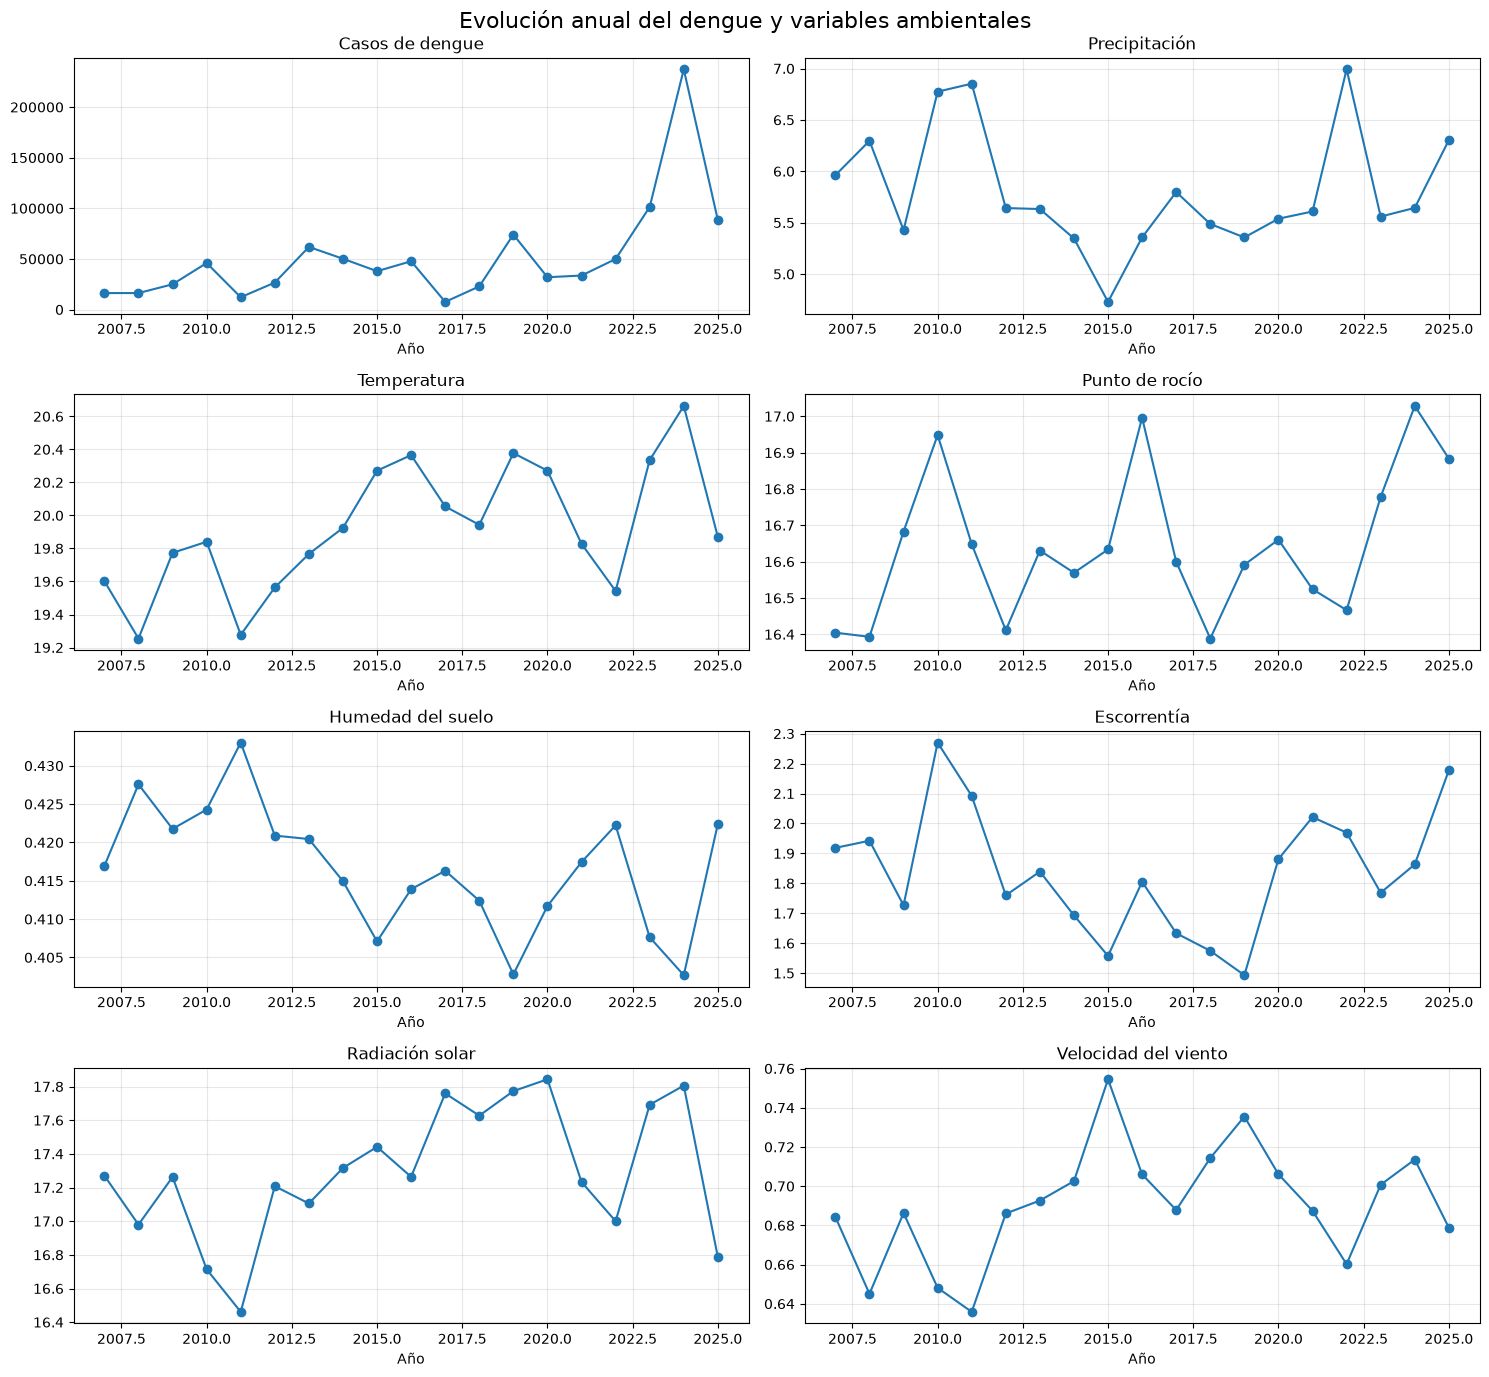

In [6]:
# ============================================================
# ANÁLISIS DE FEATURES - COMPORTAMIENTO ANUAL
# ============================================================

import math
import matplotlib.pyplot as plt


# ============================================================
# 1. VARIABLES A VISUALIZAR
# ============================================================

features = {
    "casos_dengue": "Casos de dengue",
    "rain_mm_day": "Precipitación",
    "temp_mean_c": "Temperatura",
    "dewpoint_mean_c": "Punto de rocío",
    "soil_water_l1_mean": "Humedad del suelo",
    "surface_runoff_mm_day": "Escorrentía",
    "solar_radiation_mj_m2_day": "Radiación solar",
    "wind_speed_mean_ms": "Velocidad del viento"
}


# ============================================================
# 2. CREAR AÑO
# ============================================================

dataset_base["year"] = dataset_base["date"].dt.year


# ============================================================
# 3. AGREGACIÓN ANUAL
# ============================================================

agregaciones = {
    feature: "mean"
    for feature in features
}

agregaciones["casos_dengue"] = "sum"

dataset_anual = (
    dataset_base
    .groupby("year")
    .agg(agregaciones)
    .reset_index()
)


# ============================================================
# 4. MOSAICO DE FEATURES
# ============================================================

columnas = 2
filas = math.ceil(len(features) / columnas)

fig, axes = plt.subplots(
    filas,
    columnas,
    figsize=(15, filas * 3.5)
)

axes = axes.flatten()

for ax, (feature, titulo) in zip(axes, features.items()):

    ax.plot(
        dataset_anual["year"],
        dataset_anual[feature],
        marker="o"
    )

    ax.set_title(titulo)
    ax.set_xlabel("Año")
    ax.grid(alpha=0.3)

for ax in axes[len(features):]:
    ax.remove()

plt.suptitle(
    "Evolución anual del dengue y variables ambientales",
    fontsize=16
)

plt.tight_layout()
plt.show()

# 4. Entrenamiento, validación y pruebas
---
La separación es temporal.

- **Train:** 2007 - 2023
- **Validation:** 2024
- **Test:** 2025

El horizonte de predicción será de **21 días**.

In [7]:
# ============================================================
# DIVISIÓN TEMPORAL - LSTM
# ============================================================

HORIZON = 21

# Fecha que realmente estamos intentando predecir
dataset_lstm["target_date"] = (
    dataset_lstm["date"]
    + pd.Timedelta(days=HORIZON)
)


# ============================================================
# 1. TRAIN
# ============================================================

train_lstm = dataset_lstm[
    dataset_lstm["target_date"].dt.year <= 2023
].copy()


# ============================================================
# 2. VALIDATION
# ============================================================

validation_lstm = dataset_lstm[
    dataset_lstm["target_date"].dt.year == 2024
].copy()


# ============================================================
# 3. TEST
# ============================================================

test_lstm = dataset_lstm[
    dataset_lstm["target_date"].dt.year == 2025
].copy()


# ============================================================
# 4. VALIDACIÓN
# ============================================================

for nombre, df in {
    "TRAIN": train_lstm,
    "VALIDATION": validation_lstm,
    "TEST": test_lstm
}.items():

    print(
        nombre,
        "|",
        df["target_date"].min(),
        "->",
        df["target_date"].max(),
        "|",
        df.shape
    )

TRAIN | 2007-01-22 00:00:00 -> 2023-12-31 00:00:00 | (6908154, 14)
VALIDATION | 2024-01-01 00:00:00 -> 2024-12-31 00:00:00 | (410652, 14)
TEST | 2025-01-01 00:00:00 -> 2025-12-31 00:00:00 | (409530, 14)


# 5. Preparación de datos para LSTM
---
La LSTM necesita variables en escalas comparables.

La imputación y normalización se calculan **solo con Train** para evitar `data leakage`. Validation y Test únicamente reutilizan esas estadísticas.

In [8]:
# ============================================================
# TRATAMIENTO DE NULOS Y NORMALIZACIÓN - LSTM
# ============================================================

from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. IMPUTACIÓN
# ============================================================

# Medianas calculadas únicamente con TRAIN.
medianas_train = (
    train_lstm[features_lstm]
    .median()
)

for df in [
    train_lstm,
    validation_lstm,
    test_lstm
]:
    df[features_lstm] = (
        df[features_lstm]
        .fillna(medianas_train)
    )


# ============================================================
# 2. NORMALIZACIÓN
# ============================================================

scaler = StandardScaler()

scaler.fit(
    train_lstm[features_lstm]
)

train_lstm[features_lstm] = scaler.transform(
    train_lstm[features_lstm]
)

validation_lstm[features_lstm] = scaler.transform(
    validation_lstm[features_lstm]
)

test_lstm[features_lstm] = scaler.transform(
    test_lstm[features_lstm]
)


# ============================================================
# 3. VALIDACIÓN
# ============================================================

print("Nulos Train:")
print(
    train_lstm[features_lstm]
    .isna()
    .sum()
    .sum()
)

print(
    "\nMedia aproximada Train:",
    train_lstm[features_lstm]
    .mean()
    .mean()
)

print(
    "Desviación aproximada Train:",
    train_lstm[features_lstm]
    .std()
    .mean()
)

Nulos Train:
0

Media aproximada Train: -3.536925615579064e-18
Desviación aproximada Train: 1.0000000723782438


# 6. Creación de secuencias
---
Cada observación para la LSTM tendrá:

- **28 días de historia**
- **11 variables por día**
- un objetivo: casos de dengue **21 días después**

El target se mantiene en su escala original.

In [9]:
# ============================================================
# CREACIÓN DE SECUENCIAS - LSTM
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

LOOKBACK = 28
HORIZON = 21


# ============================================================
# 2. RECONSTRUIR DATASET NORMALIZADO COMPLETO
# ============================================================

# Unimos nuevamente los tres bloques normalizados.
# Esto permite conservar continuidad temporal entre años.

dataset_scaled = pd.concat(
    [
        train_lstm,
        validation_lstm,
        test_lstm
    ],
    ignore_index=True
)

dataset_scaled = (
    dataset_scaled
    .sort_values(["mpio_cdpmp", "date"])
    .reset_index(drop=True)
)


# ============================================================
# 3. TARGET ORIGINAL SIN NORMALIZAR
# ============================================================

target_raw = (
    dataset_lstm[
        ["date", "mpio_cdpmp", "casos_dengue"]
    ]
    .rename(
        columns={
            "casos_dengue": "target_raw"
        }
    )
)

dataset_scaled = dataset_scaled.merge(
    target_raw,
    on=["date", "mpio_cdpmp"],
    how="left"
)


# ============================================================
# 4. FUNCIÓN PARA CREAR SECUENCIAS
# ============================================================

def crear_secuencias(df):

    X = []
    y = []
    municipios = []
    fechas_target = []

    for municipio, grupo in df.groupby("mpio_cdpmp"):

        grupo = (
            grupo
            .sort_values("date")
            .reset_index(drop=True)
        )

        valores = grupo[features_lstm].to_numpy(
            dtype=np.float32
        )

        target = grupo["target_raw"].to_numpy(
            dtype=np.float32
        )

        fechas = grupo["date"].to_numpy()

        limite = len(grupo) - HORIZON

        for i in range(
            LOOKBACK - 1,
            limite
        ):

            inicio = i - LOOKBACK + 1
            fin = i + 1

            target_idx = i + HORIZON

            X.append(
                valores[inicio:fin]
            )

            y.append(
                target[target_idx]
            )

            municipios.append(
                municipio
            )

            fechas_target.append(
                fechas[target_idx]
            )

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        np.asarray(municipios),
        pd.to_datetime(fechas_target)
    )


# ============================================================
# 5. CREAR SECUENCIAS
# ============================================================

X, y, municipios_seq, fechas_target = crear_secuencias(
    dataset_scaled
)


# ============================================================
# 6. DIVIDIR POR FECHA DEL TARGET
# ============================================================

mask_train = fechas_target.year <= 2023
mask_validation = fechas_target.year == 2024
mask_test = fechas_target.year == 2025

X_train = X[mask_train]
y_train = y[mask_train]

X_validation = X[mask_validation]
y_validation = y[mask_validation]

X_test = X[mask_test]
y_test = y[mask_test]


# ============================================================
# 7. VALIDACIÓN
# ============================================================

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_validation.shape, y_validation.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nShape de una secuencia:")
print(X_train[0].shape)

Train: (6877860, 28, 11) (6877860,)
Validation: (410652, 28, 11) (410652,)
Test: (385968, 28, 11) (385968,)

Shape de una secuencia:
(28, 11)


# 7. Municipio como entrada del modelo
---
Un mismo patrón climático puede comportarse distinto según el municipio.

El código DIVIPOLA no se usa como número continuo: se convierte en un ID para aprender un **embedding por municipio**.

In [10]:
# ============================================================
# PREPARACIÓN DE MUNICIPIOS PARA EMBEDDING
# ============================================================

import numpy as np


# ============================================================
# 1. MUNICIPIOS DISPONIBLES EN TRAIN
# ============================================================

municipios_train_unicos = np.unique(
    municipios_seq[mask_train]
)

municipio_to_id = {
    municipio: i + 1
    for i, municipio in enumerate(municipios_train_unicos)
}

# 0 queda reservado para municipios desconocidos
N_MUNICIPIOS = len(municipio_to_id) + 1


# ============================================================
# 2. CONVERTIR MUNICIPIO A ID NUMÉRICO
# ============================================================

municipios_ids = np.array(
    [
        municipio_to_id.get(municipio, 0)
        for municipio in municipios_seq
    ],
    dtype=np.int32
)


# ============================================================
# 3. DIVIDIR MUNICIPIOS
# ============================================================

municipio_train = municipios_ids[mask_train]

municipio_validation = municipios_ids[
    mask_validation
]

municipio_test = municipios_ids[
    mask_test
]


# ============================================================
# 4. VALIDACIÓN
# ============================================================

print("Municipios:", N_MUNICIPIOS)

print(
    "Train:",
    X_train.shape,
    municipio_train.shape,
    y_train.shape
)

print(
    "Validation:",
    X_validation.shape,
    municipio_validation.shape,
    y_validation.shape
)

print(
    "Test:",
    X_test.shape,
    municipio_test.shape,
    y_test.shape
)

Municipios: 1123
Train: (6877860, 28, 11) (6877860,) (6877860,)
Validation: (410652, 28, 11) (410652,) (410652,)
Test: (385968, 28, 11) (385968,) (385968,)


# 8. Modelo LSTM
---
La secuencia temporal aprende la evolución de clima y casos.

El embedding aprende diferencias estructurales entre municipios.

Todavía **no entrenamos**: este notebook queda hasta la definición y compilación del modelo.

In [11]:
# ============================================================
# ARQUITECTURA LSTM + EMBEDDING DE MUNICIPIO
# ============================================================

import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout,
    Embedding,
    Flatten,
    Concatenate
)


# ============================================================
# 1. ENTRADA TEMPORAL
# ============================================================

sequence_input = Input(
    shape=(LOOKBACK, len(features_lstm)),
    name="sequence"
)

x_seq = LSTM(
    units=64,
    name="lstm"
)(sequence_input)

x_seq = Dropout(
    0.2
)(x_seq)


# ============================================================
# 2. ENTRADA MUNICIPIO
# ============================================================

municipio_input = Input(
    shape=(1,),
    dtype="int32",
    name="municipio"
)

x_mpio = Embedding(
    input_dim=N_MUNICIPIOS,
    output_dim=16,
    name="municipio_embedding"
)(municipio_input)

x_mpio = Flatten()(x_mpio)


# ============================================================
# 3. COMBINAR INFORMACIÓN
# ============================================================

x = Concatenate()([
    x_seq,
    x_mpio
])

x = Dense(
    64,
    activation="relu"
)(x)

x = Dropout(
    0.2
)(x)

x = Dense(
    32,
    activation="relu"
)(x)


# ============================================================
# 4. SALIDA
# ============================================================

# Softplus garantiza predicciones >= 0
output = Dense(
    1,
    activation="softplus",
    name="casos_dengue"
)(x)


# ============================================================
# 5. MODELO
# ============================================================

modelo_lstm = Model(
    inputs=[
        sequence_input,
        municipio_input
    ],
    outputs=output
)


# ============================================================
# 6. COMPILACIÓN
# ============================================================

modelo_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="poisson",

    metrics=[
        "mae"
    ]
)


# ============================================================
# 7. VALIDACIÓN
# ============================================================

modelo_lstm.summary()

I0000 00:00:1788341230.501705   49599 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788341234.997812   49599 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788341247.400385   49599 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1788341248.897771   49599 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence            │ (None, 28, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ municipio           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     19,456 │ sequence[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ municipio_embedding │ (None, 1, 16)     │     17,968 │ municipio[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ municipio_embedd… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      5,184 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ casos_dengue        │ (None, 1)         │         33 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 44,721 (174.69 KB)

 Trainable params: 44,721 (174.69 KB)

 Non-trainable params: 0 (0.00 B)